HEAD:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

INFO:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup 

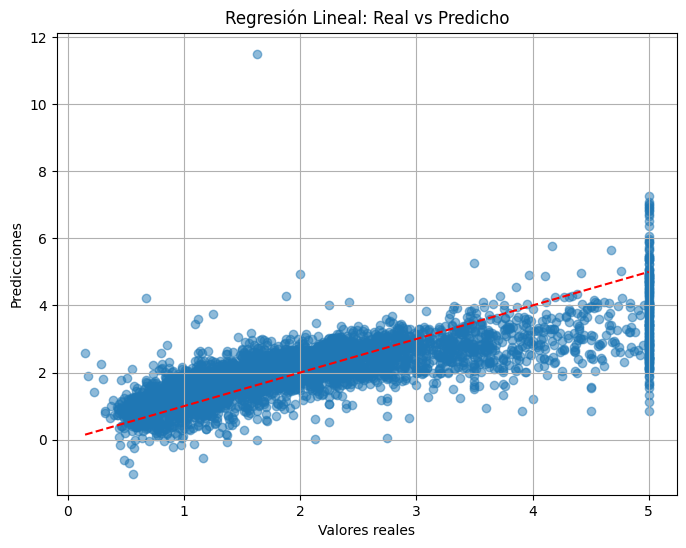


===== POLYNOMIAL REGRESSION (grado 2) =====
Train MSE: 0.4207266151573567
Test MSE: 0.4643015258024312
Train R2: 0.6852681982344946
Test R2: 0.6456819714210809


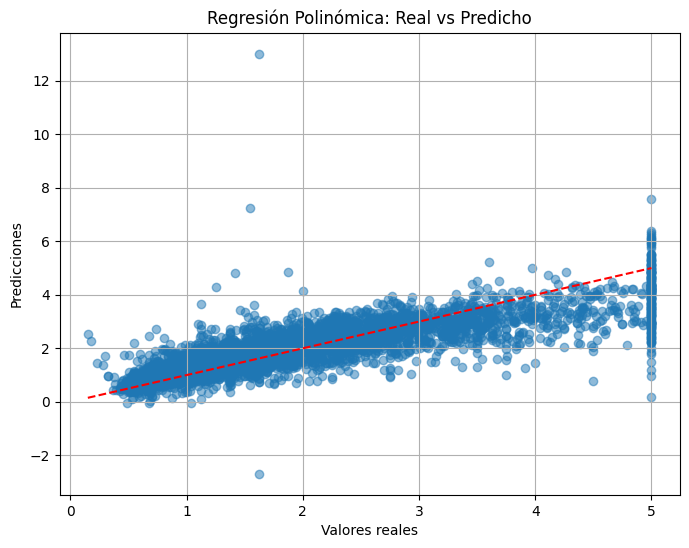


===== IMPORTANCIA DE FEATURES =====
      Feature  Coeficiente
3   AveBedrms     0.783145
0      MedInc     0.448675
7   Longitude    -0.433708
6    Latitude    -0.419792
2    AveRooms    -0.123323
1    HouseAge     0.009724
5    AveOccup    -0.003526
4  Population    -0.000002


In [8]:
# =====================================
# 1. Cargar y explorar dataset
# =====================================
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["Price"] = data.target

print("HEAD:")
print(df.head())

print("\nINFO:")
print(df.info())

print("\nDESCRIBE:")
print(df.describe())


# =====================================
# 2. Train/Test split
# =====================================
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =====================================
# 3. Regresión Lineal
# =====================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_train_pred = lin_model.predict(X_train)
y_test_pred = lin_model.predict(X_test)

lin_mse_train = mean_squared_error(y_train, y_train_pred)
lin_mse_test = mean_squared_error(y_test, y_test_pred)

lin_r2_train = r2_score(y_train, y_train_pred)
lin_r2_test = r2_score(y_test, y_test_pred)

print("\n===== LINEAR REGRESSION =====")
print("Train MSE:", lin_mse_train)
print("Test MSE:", lin_mse_test)
print("Train R2:", lin_r2_train)
print("Test R2:", lin_r2_test)


# =====================================
# 4. Gráfico lineal mejorado
# =====================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--',color="red")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal: Real vs Predicho")

plt.grid(True)
plt.show()


# =====================================
# 5. Regresión Polinómica
# =====================================
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_train_poly_pred = poly_model.predict(X_train_poly)
y_test_poly_pred = poly_model.predict(X_test_poly)

poly_mse_train = mean_squared_error(y_train, y_train_poly_pred)
poly_mse_test = mean_squared_error(y_test, y_test_poly_pred)

poly_r2_train = r2_score(y_train, y_train_poly_pred)
poly_r2_test = r2_score(y_test, y_test_poly_pred)

print("\n===== POLYNOMIAL REGRESSION (grado 2) =====")
print("Train MSE:", poly_mse_train)
print("Test MSE:", poly_mse_test)
print("Train R2:", poly_r2_train)
print("Test R2:", poly_r2_test)


# =====================================
# 6. Gráfico polinómico mejorado
# =====================================
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_poly_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--',color="red")

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Polinómica: Real vs Predicho")

plt.grid(True)
plt.show()


# =====================================
# 7. Feature más importante
# =====================================
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": lin_model.coef_
})

coef_df = coef_df.sort_values(by="Coeficiente", key=abs, ascending=False)

print("\n===== IMPORTANCIA DE FEATURES =====")
print(coef_df)

## ¿Cuál modelo es mejor? ¿Cómo lo determinaron?

El mejor modelo es la regresión polinómica (grado 2), ya que presenta un menor error (MSE) y un mayor coeficiente de determinación (R2) en el conjunto de test en comparación con la regresión lineal.

Esto se determinó comparando las métricas en test:
- El MSE (Mean Squared Error): cuanto más bajo, mejor
- El R2: cuanto más cercano a 1, mejor

En este caso, el modelo polinómico logra ajustarse mejor a los datos sin perder demasiada capacidad de generalización.

---

## ¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?

Sí, hay indicios leves de overfitting en la regresión polinómica.

Esto se observa porque:
- El rendimiento en train es mejor que en test
- El R2 en train es más alto que en test
- El MSE en train es más bajo que en test

Esto indica que el modelo polinómico se ajusta muy bien a los datos de entrenamiento, pero pierde algo de precisión en datos nuevos.

Sin embargo, la diferencia no es extrema, por lo que el overfitting no es grave.

---

## ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

El feature que tiene más impacto en el precio es **MedInc (ingreso medio de la zona)**.

Esto se determinó analizando los coeficientes del modelo de regresión lineal.  
El feature con el coeficiente de mayor valor absoluto es el más influyente.

En este caso, MedInc tiene el coeficiente más alto, lo que indica que a mayor ingreso promedio en la zona, mayor es el precio de las viviendas.